<a href="https://colab.research.google.com/github/KalkidanAI/MyFirstRepo/blob/main/customer_retail_ml_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [20]:
import io
df = pd.read_csv(io.BytesIO(uploded['Scustomer_retailcsvfile.csv']))


KeyError: 'Scustomer_retailcsvfile.csv'

In [4]:
import pandas as pd

In [21]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score, confusion_matrix



In [22]:
df = pd.read_csv("customer_retail csv file.csv")

print(df.head())
print(df.info())

  InvoiceNo StockCode                          Description  Quantity  \
0    536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1    536365     71053                  WHITE METAL LANTERN         6   
2    536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3    536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4    536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   

        InvoiceDate  UnitPrice  CustomerID         Country  
0  01-12-2010 08:26       2.55     17850.0  United Kingdom  
1  01-12-2010 08:26       3.39     17850.0  United Kingdom  
2  01-12-2010 08:26       2.75     17850.0  United Kingdom  
3  01-12-2010 08:26       3.39     17850.0  United Kingdom  
4  01-12-2010 08:26       3.39     17850.0  United Kingdom  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   

In [23]:
print(df.isnull().sum())

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [24]:
df = df.dropna()

In [25]:
print(df.isnull().sum())

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64


In [28]:
data = df[['Quantity', 'UnitPrice', 'Country']]

In [29]:
le = LabelEncoder()

data['Country'] = le.fit_transform(data['Country'])

/tmp/ipykernel_5528/3931895422.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Country'] = le.fit_transform(data['Country'])


In [30]:
data['Target'] = (data['Quantity'] > 10).astype(int)

/tmp/ipykernel_5528/4265411628.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['Target'] = (data['Quantity'] > 10).astype(int)


In [31]:
X = data[['Quantity', 'UnitPrice', 'Country']]
y = data['Target']

In [32]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

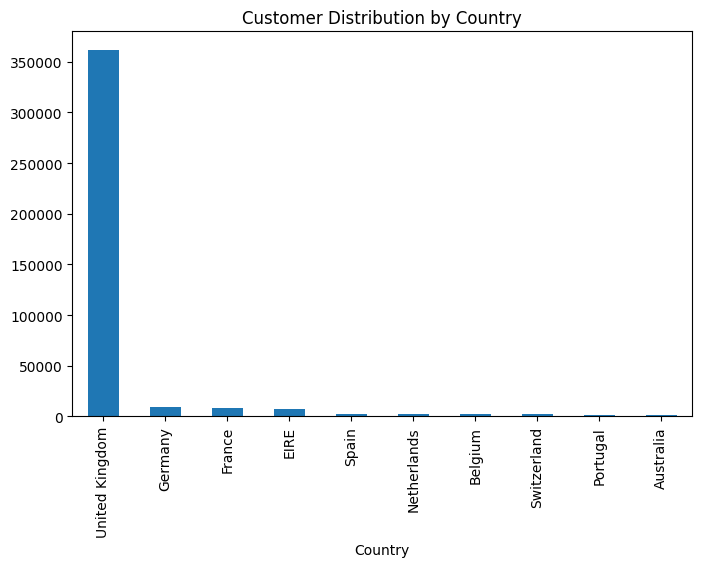

In [33]:
plt.figure(figsize=(8,5))
df['Country'].value_counts().head(10).plot(kind='bar')
plt.title('Customer Distribution by Country')
plt.show()

In [34]:
lr = LogisticRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_acc = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", lr_acc)

print(confusion_matrix(y_test, lr_pred))

Logistic Regression Accuracy: 1.0
[[56047     0]
 [    0 25319]]


In [35]:
dt = DecisionTreeClassifier()

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

dt_acc = accuracy_score(y_test, dt_pred)

print("Decision Tree Accuracy:", dt_acc)

print(confusion_matrix(y_test, dt_pred))

Decision Tree Accuracy: 1.0
[[56047     0]
 [    0 25319]]


In [36]:
knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)

knn_acc = accuracy_score(y_test, knn_pred)

print("KNN Accuracy:", knn_acc)

print(confusion_matrix(y_test, knn_pred))

KNN Accuracy: 0.9999631295627166
[[56047     0]
 [    3 25316]]


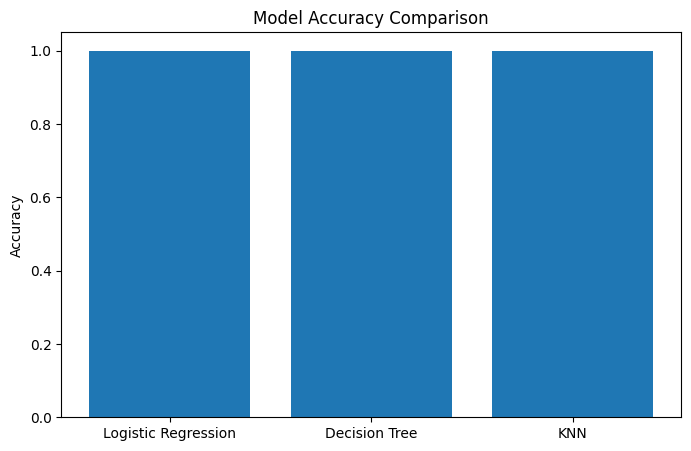

In [37]:
models = ['Logistic Regression', 'Decision Tree', 'KNN']

accuracies = [lr_acc, dt_acc, knn_acc]

plt.figure(figsize=(8,5))

plt.bar(models, accuracies)

plt.title("Model Accuracy Comparison")

plt.ylabel("Accuracy")

plt.show()